# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
import os
import re

path = 'C:/Users/david/Documents/7mo semestre/Recuperacion Informacion/ir26a/100libros/'
vocabulario = set()
corpus = {}
for file in os.listdir(path):
    with open(path+file, 'r', encoding='utf-8') as f:
        text = f.read()
        corpus[file] = text
lista_textos = list(corpus.values())

## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [20]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import string
import numpy as np
from collections import Counter
nltk.download('stopwords')

stop_words = stopwords.words('spanish') + stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
count_vec = CountVectorizer(
    token_pattern=r'\b[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]{3,}\b',
    stop_words=stop_words,
    min_df=2,
    max_df=0.95
)

tf_matrix = count_vec.fit_transform(lista_textos)
terminos = count_vec.get_feature_names_out()
tf = pd.DataFrame(tf_matrix.toarray(), index=[i for i in range(len(corpus))], columns=terminos)
df = (tf > 0).sum(axis=0)

In [11]:
print("=== Matriz TF ===")
print(tf)
print("\n=== Document Frequency (DF) ===")
print(df.sort_values(ascending=False).head(20))

=== Matriz TF ===
     aaa  aaaaah  aaaah  aaah  aaay  aac  aachen  aah  aap  aar  ...  úsese  \
0      0       0      0     0     0    0       0    0    0    0  ...      0   
1      0       0      0     0     0    0       0    0    0    0  ...      0   
2      0       0      0     0     0    0       0    0    0    0  ...      0   
3      0       0      0     0     0    0       0    0    0    0  ...      0   
4      0       0      0     0     0    0       0    0    0    0  ...      0   
..   ...     ...    ...   ...   ...  ...     ...  ...  ...  ...  ...    ...   
902    0       0      0     0     0    0       0    0    0    0  ...      0   
903    0       0      0     0     0    0       0    0    0    0  ...      0   
904    0       0      0     0     0    0       0    0    0    0  ...      0   
905    0       0      0     0     0    0       0    0    0    0  ...      0   
906    0       0      0     0     0    0       0    0    0    0  ...      0   

     útero  útica  útil  útiles  

In [12]:
vectorizador_tfidf = TfidfVectorizer(
    token_pattern=r'\b[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]{3,}\b',
    stop_words=stop_words,
    min_df=2,
    max_df=0.95
)
matriz_tfidf = vectorizador_tfidf.fit_transform(lista_textos)
terminos_tfidf = vectorizador_tfidf.get_feature_names_out()

In [13]:
tfidf = pd.DataFrame(matriz_tfidf.toarray(), index=[i for i in range(len(corpus))], columns=terminos_tfidf)

print("\n=== Matriz TF-IDF ===")
print(tfidf)


=== Matriz TF-IDF ===
     aaa  aaaaah  aaaah  aaah  aaay  aac  aachen  aah  aap  aar  ...  úsese  \
0    0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
1    0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
2    0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
3    0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
4    0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
..   ...     ...    ...   ...   ...  ...     ...  ...  ...  ...  ...    ...   
902  0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
903  0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
904  0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
905  0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   
906  0.0     0.0    0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  ...    0.0   

     útero  útica      útil 

In [14]:
tfidf_promedio = tfidf.mean(axis=0).sort_values(ascending=False)
tf_promedio = tf.mean(axis=0).sort_values(ascending=False)

comparacion = pd.DataFrame({
    "TF_promedio": tf_promedio,
    "TF-IDF_promedio": tfidf_promedio,
    "DF": df
}).dropna().sort_values("TF-IDF_promedio", ascending=False)

print("\n=== Comparación TF vs TF-IDF ===")
print(comparacion.head(30))


=== Comparación TF vs TF-IDF ===
          TF_promedio  TF-IDF_promedio   DF
usted       82.373760         0.069722  542
dijo        89.857773         0.046591  818
después     66.560088         0.044463  740
así         77.027563         0.043417  853
fué         58.185226         0.042555  623
casa        74.672547         0.040148  861
mas         78.001103         0.039595  810
señor       76.626240         0.035569  849
día         47.807056         0.034401  729
dios        67.534730         0.033473  858
aquí        58.796031         0.033100  854
ojos        50.047409         0.031067  838
sólo        37.619625         0.030738  656
menos       44.730981         0.027809  832
allí        49.359427         0.027507  848
habia       28.593164         0.026706  215
entonces    44.746417         0.026500  835
mujer       41.138920         0.026363  775
padre       47.605292         0.025638  844
noche       42.854465         0.025511  855
hombres     42.453142         0.024302  85

## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Vector de consulta
consulta = "una especie de recelo sobrecogido y la misma gravedad dolorosa"

vector_consulta = vectorizador_tfidf.transform([consulta])

# 2. Similitud coseno entre la consulta y cada documento
similitudes = cosine_similarity(vector_consulta, matriz_tfidf).flatten()

# 3 y 4. Ranking en tabla
ranking = pd.DataFrame({
    'documento': list(corpus.keys()),
    'similitud': similitudes
}).sort_values('similitud', ascending=False).reset_index(drop=True)

ranking.index += 1
print(ranking)

                                             documento  similitud
1    Naturaleza de las cosas Versión en prosa del p...   0.021775
2    Esploración arqueológica de la Provincia de Ca...   0.021141
3                                       Bug-Jargal.txt   0.020596
4                      La Novela de un Joven Pobre.txt   0.019319
5    I. Origen de los indios de América. II. Origen...   0.018161
..                                                 ...        ...
903  El derecho internacional americano estudio doc...   0.000000
904  Discursos sobre el arte del dançado y sus exel...   0.000000
905                          A Flor De Piel Frases.txt   0.000000
906                         A First Spanish Reader.txt   0.000000
907                      40 years  40 años  40 ans.txt   0.000000

[907 rows x 2 columns]


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [18]:
start_pattern = r'\*\*\* START OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*'

def preprocess_text(text: str)-> list:
    partes = re.split(start_pattern, text)
    if len(partes) > 1:
        text = partes[1]
    lower_text = text.lower()
    clean_text = re.sub(r'\d+', '', lower_text)
    clean_text = clean_text.translate(str.maketrans('', '', string.punctuation))
    tokens = clean_text.split()
    stop_words = set(stopwords.words('spanish'))
    clean_tokens  = [word for word in tokens if word not in stop_words]
    return clean_tokens

In [24]:
# Parámetros BM25
k1 = 1.5
b = 0.75

# 1. Tokenización (reutiliza tu preprocesamiento)
corpus_tokenizado = [preprocess_text(texto) for texto in lista_textos]

# 2. Longitudes de documentos y promedio
longitudes = [len(doc) for doc in corpus_tokenizado]
avgdl = np.mean(longitudes)
N = len(corpus_tokenizado)

# 3. TF por documento
def calcular_tf(documento):
    return Counter(documento)

tfs = [calcular_tf(doc) for doc in corpus_tokenizado]

# 4. DF e IDF de BM25
df_bm25 = Counter()
for doc in corpus_tokenizado:
    for termino in set(doc):
        df_bm25[termino] += 1

def idf_bm25(termino):
    df = df_bm25.get(termino, 0)
    return np.log((N - df + 0.5) / (df + 0.5) + 1)

# 6. Score BM25 para un documento
def score_bm25_documento(consulta_tokens, doc_idx):
    score = 0
    tf = tfs[doc_idx]
    dl = longitudes[doc_idx]
    
    for termino in consulta_tokens:
        if termino not in tf:
            continue
        tf_td = tf[termino]
        idf = idf_bm25(termino)
        numerador = tf_td * (k1 + 1)
        denominador = tf_td + k1 * (1 - b + b * (dl / avgdl))
        score += idf * (numerador / denominador)
    
    return score

# 7. Scores para toda la colección
def ranking_bm25(consulta_str):
    consulta_tokens = preprocess_text(consulta_str)
    scores = [score_bm25_documento(consulta_tokens, i) for i in range(N)]
    return scores

# 8. Ranking
consulta = "una especie de recelo sobrecogido y la misma gravedad dolorosa"
scores_bm25 = ranking_bm25(consulta)

ranking_bm25_df = pd.DataFrame({
    'documento': list(corpus.keys()),
    'score_bm25': scores_bm25
}).sort_values('score_bm25', ascending=False).reset_index(drop=True)

ranking_bm25_df.index += 1
print("=== Ranking BM25 ===")
print(ranking_bm25_df)

# Comparación con TF-IDF
tfidf_para_merge = ranking[['documento', 'similitud']].copy()
tfidf_para_merge['rank_tfidf'] = ranking.index

bm25_para_merge = ranking_bm25_df[['documento', 'score_bm25']].copy()
bm25_para_merge['rank_bm25'] = ranking_bm25_df.index

comparacion = bm25_para_merge.merge(tfidf_para_merge, on='documento', how='inner')
comparacion = comparacion.sort_values('rank_bm25').reset_index(drop=True)

print("\n=== Comparación BM25 vs TF-IDF ===")
print(comparacion[['documento', 'rank_bm25', 'score_bm25', 'rank_tfidf', 'similitud']])

=== Ranking BM25 ===
                                             documento  score_bm25
1                         Adriana Zumarán (novela).txt    7.689745
2                                        Volvoreta.txt    7.425947
3                        La novela de un novelista.txt    6.797377
4                       La Esfinge Maragata Novela.txt    6.791715
5                     Amparo (Memorias de un loco).txt    6.789169
..                                                 ...         ...
903                       La Bella Cubano Habenera.txt    0.000000
904                                   The Crucible.txt    0.000000
905  Doctrina Christiana The first book printed in ...    0.000000
906                                 Junto Al Pasig.txt    0.000000
907        20 poemas para ser leídos en el tranvía.txt    0.000000

[907 rows x 2 columns]

=== Comparación BM25 vs TF-IDF ===
                                             documento  rank_bm25  score_bm25  \
0                         Adriana 

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.

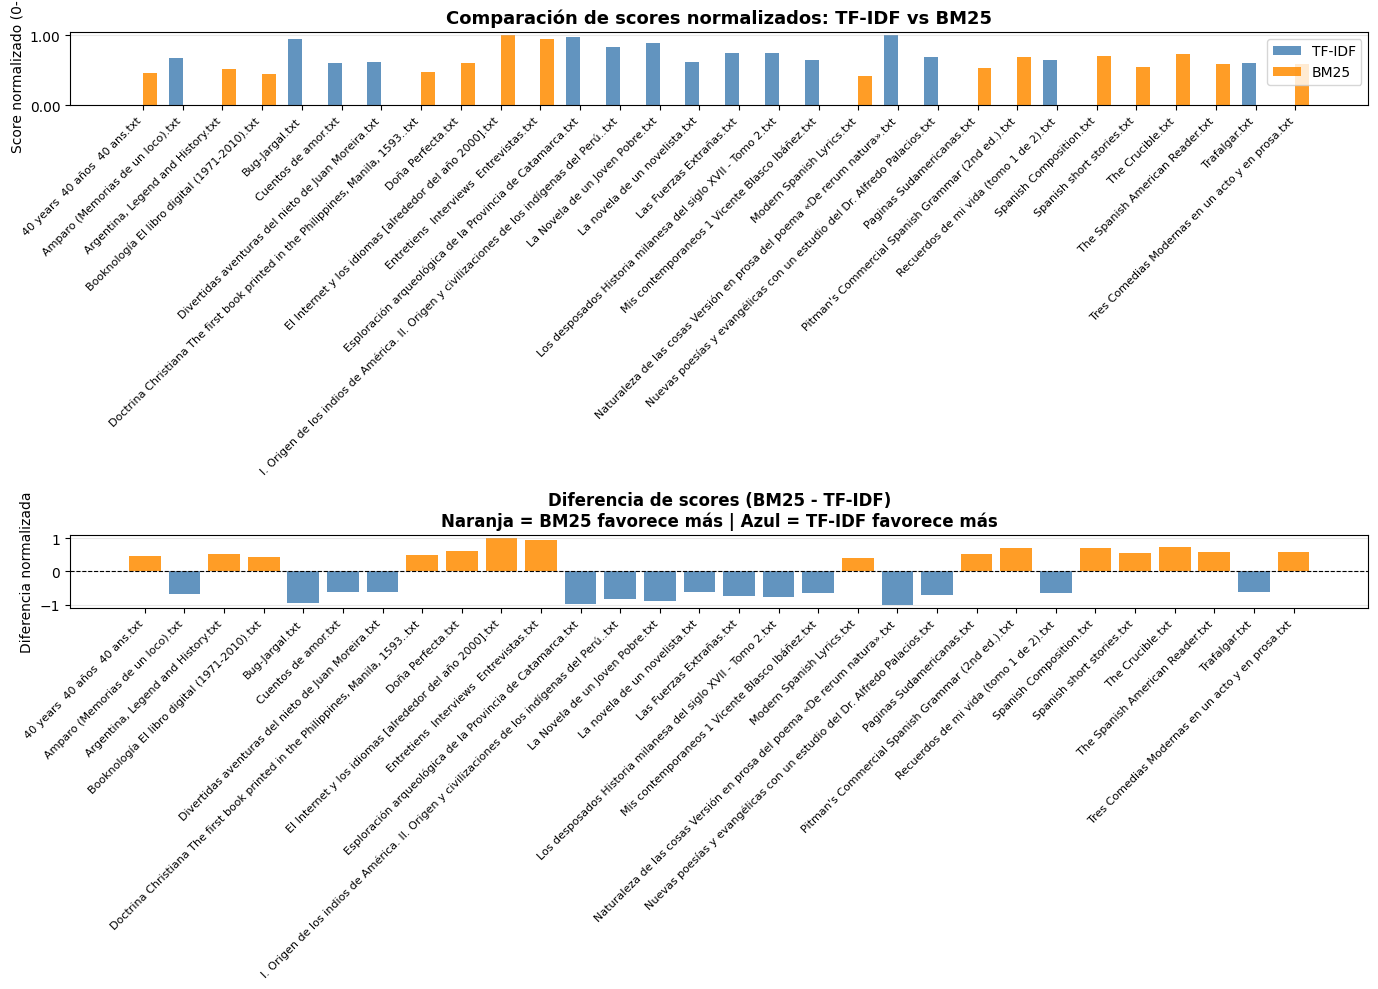

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Top N para visualizar (todos si son pocos, si no limita a 10-15)
TOP_N = 15  

# Preparar datos normalizados para comparar en la misma escala
tfidf_top = ranking.head(TOP_N).copy()
bm25_top = ranking_bm25_df.head(TOP_N).copy()

# Normalizar scores entre 0 y 1 para comparación justa
tfidf_top['similitud_norm'] = tfidf_top['similitud'] / tfidf_top['similitud'].max()
bm25_top['score_norm'] = bm25_top['score_bm25'] / bm25_top['score_bm25'].max()

# Merge para tener ambos scores por documento
comparacion_visual = tfidf_top[['documento', 'similitud_norm']].merge(
    bm25_top[['documento', 'score_norm']],
    on='documento',
    how='outer'
).fillna(0)

docs = comparacion_visual['documento'].astype(str)
x = np.arange(len(docs))
ancho = 0.35

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfico 1: Barras agrupadas comparando ambos modelos ---
ax1 = axes[0]
bars1 = ax1.bar(x - ancho/2, comparacion_visual['similitud_norm'], ancho,
                label='TF-IDF', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x + ancho/2, comparacion_visual['score_norm'], ancho,
                label='BM25', color='darkorange', alpha=0.85)

ax1.set_title('Comparación de scores normalizados: TF-IDF vs BM25', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score normalizado (0-1)')
ax1.set_xticks(x)
ax1.set_xticklabels(docs, rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax1.grid(axis='y', alpha=0.3)

# --- Gráfico 2: Diferencia BM25 - TF-IDF ---
ax2 = axes[1]
diferencia = comparacion_visual['score_norm'] - comparacion_visual['similitud_norm']
colores = ['darkorange' if d > 0 else 'steelblue' for d in diferencia]

ax2.bar(x, diferencia, color=colores, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Diferencia de scores (BM25 - TF-IDF)\nNaranja = BM25 favorece más | Azul = TF-IDF favorece más',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Diferencia normalizada')
ax2.set_xticks(x)
ax2.set_xticklabels(docs, rotation=45, ha='right', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_tfidf_bm25.png', dpi=150, bbox_inches='tight')
plt.show()

3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?

- TF-IDF favorece más a Entretiens Interviews Entrevistas, Origen de los indios de América, La Novela de un Joven Pobre, Mis contemporáneos, entre otros.
- BM25 favorece más a El Internet y los idiomas, Doña Perfecta, 40 years 40 ans, Cuentos de amor.

4. ¿A qué se podría deber esta diferencia?

La diferencia entre los dos modelos viene de cómo cada uno maneja la frecuencia y el tamaño de los documentos. TF-IDF simplemente acumula: mientras más veces aparezca un término, mayor el score, sin importar qué tan largo sea el documento. BM25 es más "justo" en ese sentido, porque limita cuánto puede crecer el score por repetición y además ajusta según la longitud del documento comparada con el promedio del corpus. Por eso documentos cortos pero con términos relevantes bien concentrados suben en BM25, mientras que en TF-IDF los libros largos casi siempre llevan ventaja.
